In [2]:
import pandas as pd

In [ ]:
data = pd.read_csv("german_credit.csv")

Определим, есть ли пропуски в данных

In [10]:
data.isna().sum()

status                     0
duration                   0
credit_history             0
purpose                    0
amount                     0
savings                    0
employment_duration        0
installment_rate           0
personal_status_sex        0
other_debtors              0
present_residence          0
property                   0
age                        0
other_installment_plans    0
housing                    0
number_credits             0
job                        0
people_liable              0
telephone                  0
foreign_worker             0
credit_risk                0
dtype: int64

Посмотрим среднюю сумму кредита

In [11]:
data.groupby("purpose")["amount"].mean()

purpose
business               8209.333333
car (new)              5370.223301
car (used)             3066.983425
domestic appliances    2728.090909
furniture/equipment    2487.685714
others                 3062.948718
radio/television       1498.000000
repairs                3180.400000
retraining             4158.041237
vacation               1205.888889
Name: amount, dtype: float64

Проверим, какой процент людей моложе 30 и 40 лет снимает жилье

In [20]:
print(len(data[data["housing"] == "rent"][data["age"] < 30])/len(data[data["age"] < 30]) * 100)
print(len(data[data["housing"] == "rent"][data["age"] > 40])/len(data[data["age"] > 40]) * 100)

66.66666666666666
68.01470588235294


C:\Users\пользователь\AppData\Local\Temp\ipykernel_6176\1203585280.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  print(len(data[data["housing"] == "rent"][data["age"] < 30])/len(data[data["age"] < 30]) * 100)
C:\Users\пользователь\AppData\Local\Temp\ipykernel_6176\1203585280.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  print(len(data[data["housing"] == "rent"][data["age"] > 40])/len(data[data["age"] > 40]) * 100)


Изучим количество кредитов у иностранцев

In [ ]:
data[data["foreign_worker"] == "yes"]["number_credits"].value_counts()

1      25
2-3    11
4-5     1
Name: number_credits, dtype: int64

Разделим данные на бинарные, категориальные количественные и порядковые 

In [ ]:
data_cat = data[[
  "credit_history",
  "purpose",
  "personal_status_sex",
  "other_debtors",
  "property",
  "other_installment_plans",
  "housing",
  "job"
]]

data_order = data[[
  "status",           
  "savings",           
  "employment_duration"  
]]

data_num = data[[
  "duration",
  "amount",
  "installment_rate",
  "present_residence",
  "age",
  "number_credits",
  "people_liable"
]]

data_bin = data[[
  "telephone",
  "foreign_worker"
]]

In [29]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

Демонстрация работы numpy и plt на простом примере с тригонометрическими функциями

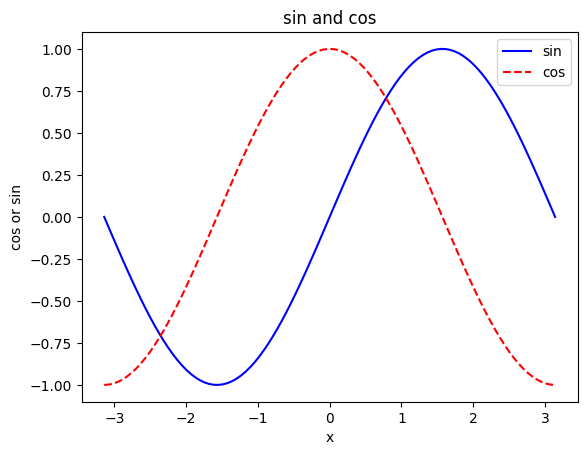

In [35]:
x = np.linspace(-np.pi, np.pi, 100)
sin = np.sin(x)
cos = np.cos(x)
plt.plot(x, sin, label="sin", color='b')
plt.plot(x, cos, label="cos", color='r', ls="dashed")
plt.title("sin and cos")
plt.xlabel('x')
plt.ylabel('cos or sin')
plt.legend()



Рассмотрим сравнительное количество положительных и отрицательных кейсов в зависимости от размера текущего счёта

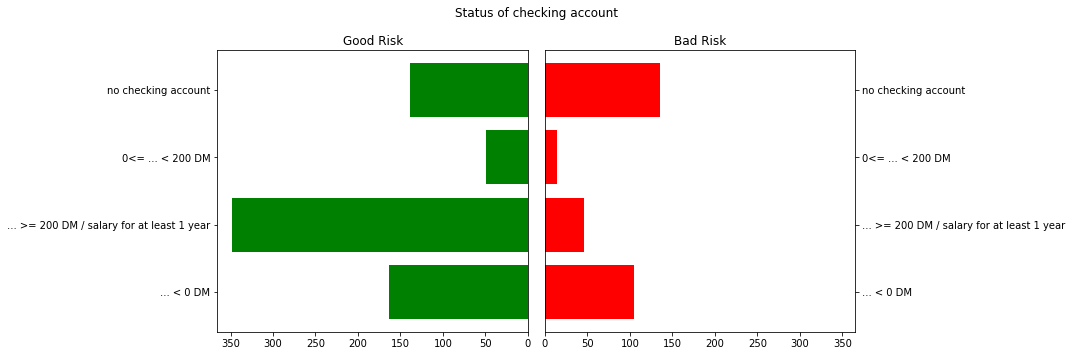

In [ ]:
fig, axs = plt.subplots(1, 2)
axs[0].barh(data["status"].unique()[::-1] ,data[data["credit_risk"] == "good"]["status"].value_counts(sort=False)[::-1], color='g')
axs[0].invert_xaxis()
axs[1].barh(data["status"].unique()[::-1] ,data[data["credit_risk"] == "bad"]["status"].value_counts(sort=False)[::-1], color='r')
axs[1].yaxis.tick_right()
axs[1].set_xlim(0, 350)

In [36]:
import seaborn as sns

Теперь построим гистограмму для сравнения количества положительных и отрицательных кейсов в зависимости от размера сберегательного счёта с помощью seaborn. 

<Axes: xlabel='savings', ylabel='count'>

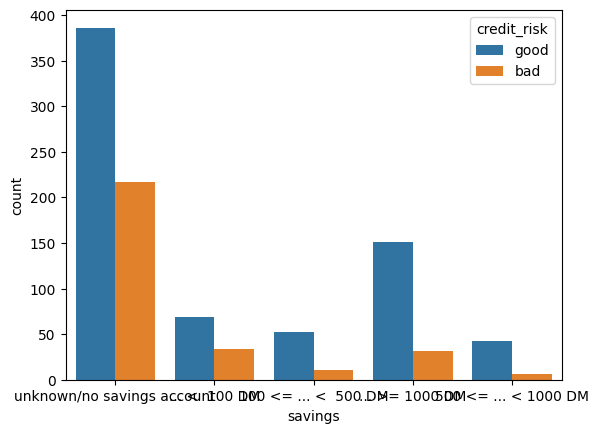

In [ ]:
plt.rcParams["figure.figsize"] = (15, 5)
sns.countplot(data, x="savings", hue="credit_risk")

seaborn легко позволяет добавить ещё больше информации на один график. Для каждого размера сберегательного счёта мы можем оценить не только количество положительных и отрицательных кейсов, но и их распределение по возрасту, например

<Axes: xlabel='savings', ylabel='age'>

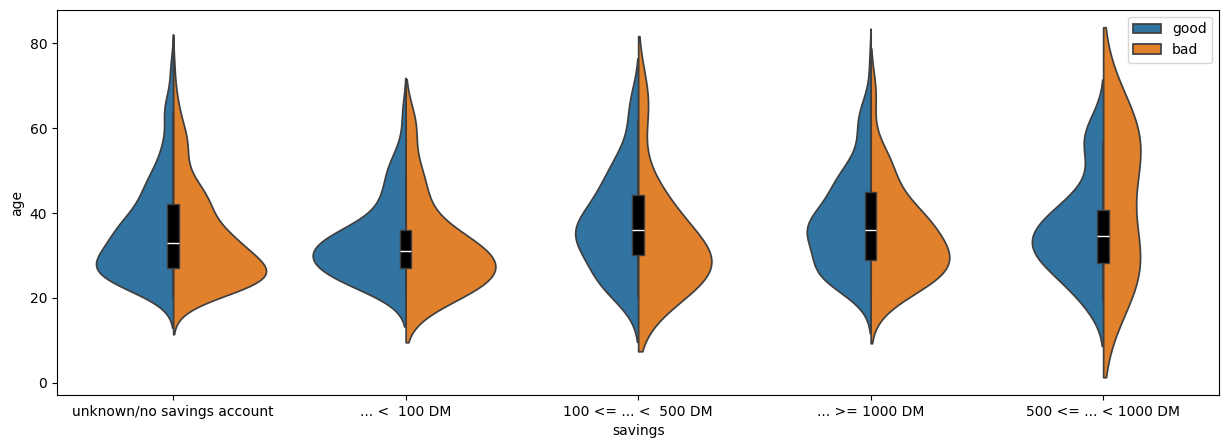

In [ ]:
plt.rcParams["figure.figsize"] = (15, 5)
sns.violinplot(data, x="savings", y="age", hue="credit_risk", inner=None, split=True)
sns.boxplot(
    data=data[data["credit_risk"] == "good"],
    x="savings",
    y="age",
    width=0.05,       # чтобы не перекрывал violin
    showcaps=False,
    showfliers=False,
    whiskerprops={'linewidth':1.5},
    medianprops={'color':'w'}, 
    boxprops={'facecolor':'black'}
)
plt.legend(title="credit_risk")


Заканчивая с гистограммами, посмотрим на распределение положительных и отрицательных кейсов по возрастам, разместив их друг над другом. Добавим распределение всех взятых кредитов.

(array([150., 219., 178., 154., 100.,  76.,  44.,  28.,  28.,  16.,   7.]),
 array([19.        , 24.09090909, 29.18181818, 34.27272727, 39.36363636,
        44.45454545, 49.54545455, 54.63636364, 59.72727273, 64.81818182,
        69.90909091, 75.        ]),
 <BarContainer object of 11 artists>)

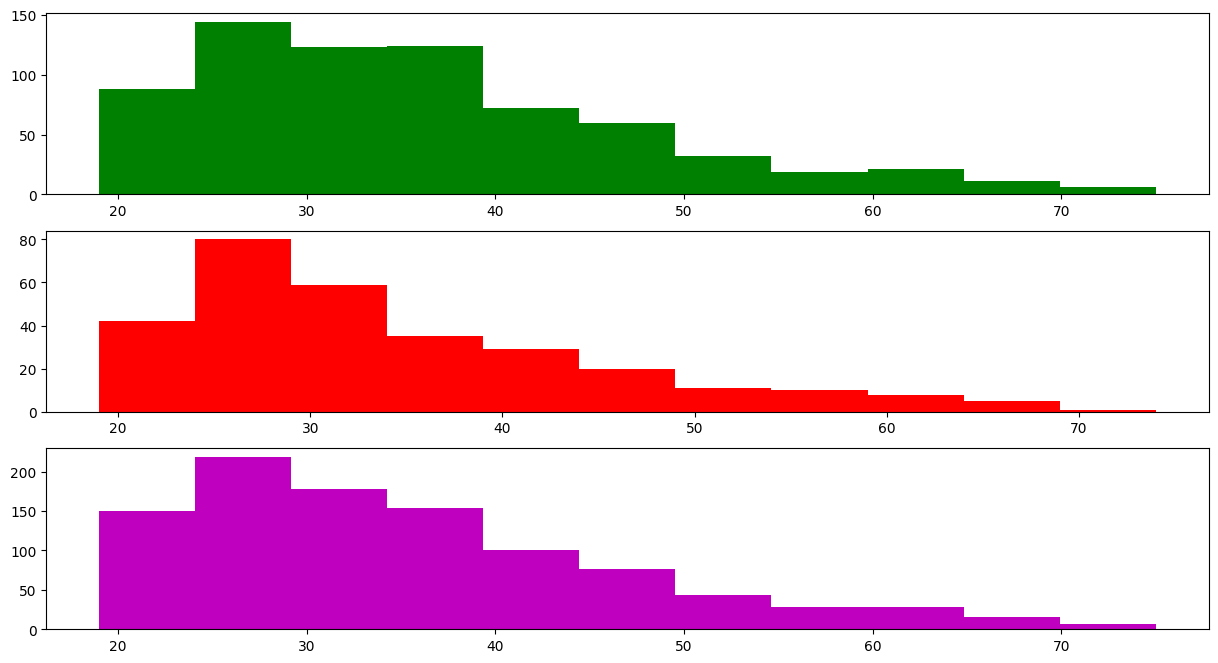

In [ ]:
fig, axs = plt.subplots(3,1)
plt.rcParams["figure.figsize"] = (8, 8)
axs[0].hist(data[data["credit_risk"] == "good"]["age"], bins=11, color='g', label="Good credits dist")
axs[0].set_ylim(0, 200)
axs[1].hist(data[data["credit_risk"] == "bad"]["age"], bins=11, color='r', label="Bad credits dist")
axs[1].set_ylim(0, 200)
axs[2].hist(data["age"], bins=11, color='m', label="All credits dist")

fig.legend()#loc="upper right")
plt.show()



Построим диаграмму рассеяния с продолжительностью и размерами кредитов в качестве осей. 

<Axes: xlabel='amount', ylabel='duration'>

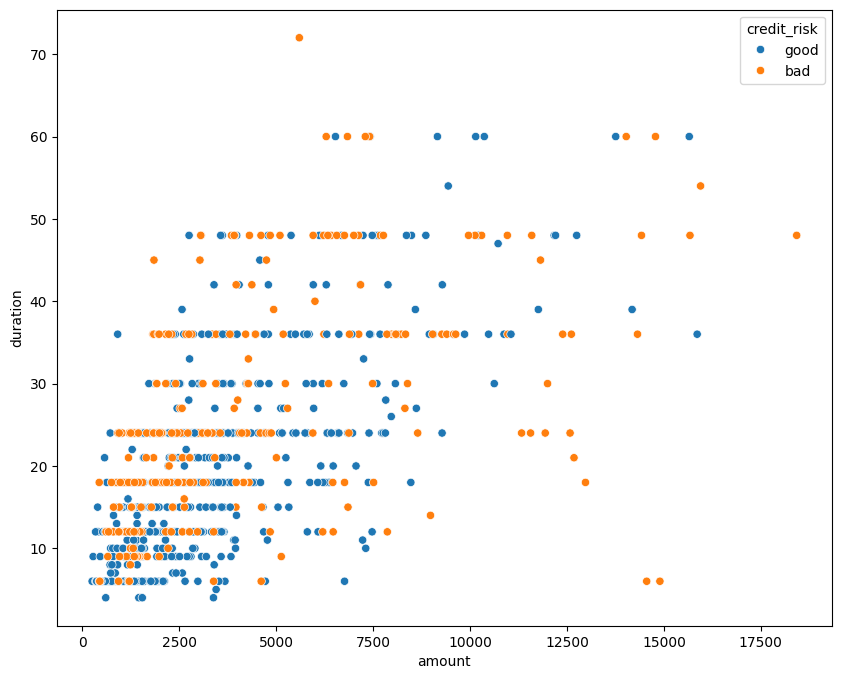

In [ ]:
plt.rcParams["figure.figsize"] = (10, 5)
sns.scatterplot(data, x="amount", y="duration", hue="credit_risk")

### Задание 12  (1 балл)

Продвинемся глубже. Постройте 3D версию диаграммы рассеяния, добавив ось с возрастом.

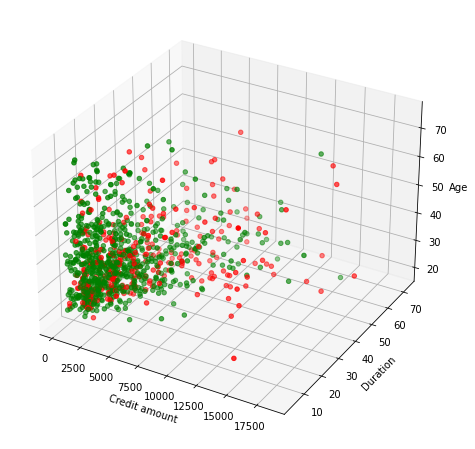

In [ ]:
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure(figsize=(20, 5))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(data[data["credit_risk"] == "good"]["amount"], data[data["credit_risk"] == "good"]["duration"], data[data["credit_risk"] == "good"]["age"], color='g')
ax.scatter(data[data["credit_risk"] == "bad"]["amount"], data[data["credit_risk"] == "bad"]["duration"], data[data["credit_risk"] == "bad"]["age"], color='r')
ax.set_xlabel('amount')
ax.set_ylabel('duration')
ax.set_zlabel('age')

Представим все порядковые и бинарные признаки в виде числовых значений {0, ..., n - 1}, где n это количество значений признака. Избавимся от категориальных признаков.

In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for feat_type in [data_cat.columns, data_bin.columns, data_order.columns]:
    for feat in feat_type:
        data[feat+"_decoded"] = le.fit_transform(data[feat])
data.head()